# Data Cleaning 

This notebook will teach you the basics of data cleaning using simple pandas functions.

**What we'll learn:**
1. Load data from a CSV file
2. Look at our data using built-in functions
3. Find missing values
4. Handle missing values
5. Save our clean data

**Instructions:**
- Upload your CSV file to Google Colab
- Change the file name in the code below
- Run each cell one by one

In [2]:
# Import pandas - our main tool for working with data
# Import numpy - a library for numerical operations
# Import matplotlib - for creating simple plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Your Data

First, let's load our CSV file and take a look at it.

In [4]:
# Load your data - change the filename to match your data file
df = pd.read_csv('../datasets/synthetic_health_lifestyle_dataset.csv')

print("Data loaded successfully!")
print(f"Our dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Data loaded successfully!
Our dataset has 7510 rows and 13 columns


In [5]:
# Look at the first 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,ID,Age,Gender,Height_cm,Weight_kg,BMI,Smoker,Exercise_Freq,Diet_Quality,Alcohol_Consumption,Chronic_Disease,Stress_Level,Sleep_Hours
0,1,56,Other,177.6,37.3,11.8,Yes,NaN,Poor,NaN,No,9,8.5
1,2,69,Other,169.3,70.7,24.7,No,1-2 times/week,Good,High,No,2,5.9
2,3,46,Female,159.1,69.0,27.3,No,Daily,Excellent,Moderate,No,3,4.8
3,4,32,Male,170.6,76.4,26.3,No,3-5 times/week,Excellent,Moderate,No,9,6.6
4,5,60,Male,158.4,60.4,24.1,No,3-5 times/week,Excellent,Low,Yes,6,6.1


## 2. Explore Your Data

Let's use built-in pandas functions to understand our data better.

In [6]:
# Get basic information about our data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7510 entries, 0 to 7509
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   7510 non-null   int64  
 1   Age                  7510 non-null   int64  
 2   Gender               7510 non-null   object 
 3   Height_cm            7510 non-null   float64
 4   Weight_kg            7504 non-null   float64
 5   BMI                  7510 non-null   float64
 6   Smoker               7510 non-null   object 
 7   Exercise_Freq        5630 non-null   object 
 8   Diet_Quality         7510 non-null   object 
 9   Alcohol_Consumption  5617 non-null   object 
 10  Chronic_Disease      7510 non-null   object 
 11  Stress_Level         7510 non-null   int64  
 12  Sleep_Hours          7510 non-null   float64
dtypes: float64(4), int64(3), object(6)
memory usage: 762.9+ KB


In [7]:
# Get statistics for numerical columns
df.describe()

,ID,Age,Height_cm,Weight_kg,BMI,Stress_Level,Sleep_Hours
count,7510.000000,7510.000000,7510.000000,7504.000000,7510.000000,7510.000000,7510.000000
mean,3755.486684,43.657923,164.948881,70.027425,26.030866,5.593609,7.002051
std,2168.071590,14.936881,9.959488,14.740438,6.431623,2.865421,1.515314
min,1.000000,18.000000,124.500000,17.700000,6.500000,1.000000,1.000000
25%,1878.250000,31.000000,158.100000,59.900000,21.600000,3.000000,6.000000
50%,3755.500000,43.000000,164.900000,70.100000,25.600000,6.000000,7.000000
75%,5632.750000,57.000000,171.600000,80.100000,30.100000,8.000000,8.000000
max,7500.000000,119.000000,197.000000,128.500000,56.800000,10.000000,12.600000


In [8]:
# Look at all column names
print("Column names in our dataset:")
print(df.columns.tolist())

Column names in our dataset:
['ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Smoker', 'Exercise_Freq', 'Diet_Quality', 'Alcohol_Consumption', 'Chronic_Disease', 'Stress_Level', 'Sleep_Hours']


In [9]:
# Check what type of data each column contains
print("Data types for each column:")
df.dtypes

Data types for each column:


ID                       int64
Age                      int64
Gender                  object
Height_cm              float64
Weight_kg              float64
BMI                    float64
Smoker                  object
Exercise_Freq           object
Diet_Quality            object
Alcohol_Consumption     object
Chronic_Disease         object
Stress_Level             int64
Sleep_Hours            float64
dtype: object

## 3 Check for Duplicates

In [10]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 10


In [11]:
# Remove duplicate rows if any
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows.")
else:
    print("No duplicate rows found.")

Removed 10 duplicate rows.


## 4. Check for Missing Values

Missing values are empty cells in our data. Let's find them!

In [12]:
# Check how many missing values each column has
df.isnull().sum()

ID                        0
Age                       0
Gender                    0
Height_cm                 0
Weight_kg                 6
BMI                       0
Smoker                    0
Exercise_Freq          1879
Diet_Quality              0
Alcohol_Consumption    1892
Chronic_Disease           0
Stress_Level              0
Sleep_Hours               0
dtype: int64

In [13]:
# Let's see which columns have missing values
columns_with_missing = df.columns[df.isnull().any()].tolist()
print("Columns with missing values:")
print(columns_with_missing)

Columns with missing values:
['Weight_kg', 'Exercise_Freq', 'Alcohol_Consumption']


In [14]:
# Look at the range of values for one specific column (change the column name as needed)
column_name = 'Weight_kg'  # Change this to any column you want to examine
print(f"Unique values in '{column_name}':")
print(df[column_name].value_counts())

Unique values in 'Weight_kg':
Weight_kg
62.1     31
71.4     29
69.0     29
70.2     29
80.1     29
         ..
43.2      1
36.3      1
119.8     1
24.0      1
26.9      1
Name: count, Length: 771, dtype: int64


Checking the categories/possible values of each column can also help identify potential spelling mistakes and typos.
e.g. England vs. Englnd 

## 5. Handle Missing Values

Now let's fix the missing values. We have several options:
- Remove rows with missing values
- Fill missing values with a specific value
- Fill missing values with the average/most common value

In [15]:
# Option 1: Remove rows with ANY missing values
df_no_missing = df.dropna()
print(f"Original data: {df.shape[0]} rows")
print(f"After removing missing: {df_no_missing.shape[0]} rows")

Original data: 7500 rows
After removing missing: 4194 rows


In [16]:
# Option 2: Fill missing values with a specific value (example: 'Unknown')
df_filled = df.fillna('Unknown')
print(f"\nAfter filling missing values with 'Unknown':")
print(df_filled.isnull().sum().sum(), "missing values remain")


After filling missing values with 'Unknown':
0 missing values remain


In [17]:
# Option 3: Fill missing values - numbers with mean, text with mode (most common value)
df_filled_smart = df.copy()

# Fill numeric columns with mean
numeric_columns = df.select_dtypes(include=[np.number]).columns
df_filled_smart[numeric_columns] = df_filled_smart[numeric_columns].fillna(df[numeric_columns].mean())

# Fill categorical columns with mode (most common value)
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
	mode_value = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
	df_filled_smart[col] = df_filled_smart[col].fillna(mode_value)

print(f"\nAfter filling missing values smartly:")
print(df_filled_smart.isnull().sum())


After filling missing values smartly:
ID                     0
Age                    0
Gender                 0
Height_cm              0
Weight_kg              0
BMI                    0
Smoker                 0
Exercise_Freq          0
Diet_Quality           0
Alcohol_Consumption    0
Chronic_Disease        0
Stress_Level           0
Sleep_Hours            0
dtype: int64


In [18]:
# Choose which cleaned version you want to use
# e.g., Option 1: Data with missing values removed
df = df_filled_smart

# For now, let's just check our final data
# Final check of our data
print("Final check - shape of our data:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")


Final check - shape of our data:
Rows: 7500, Columns: 13
Missing values: 0


## 6. Check for Outliers and Data Errors

Let's look for unusual values that might be errors in our data.

In [19]:
# Look for extreme values in numerical columns
print("Checking for potential outliers in numerical data:")
print("=" * 50)

# Get numerical columns only
numerical_cols = df.select_dtypes(include=[np.number]).columns

# Show min and max values for each numerical column
for col in numerical_cols:
    print(f"{col}:")
    print(f"  Minimum: {df[col].min()}")
    print(f"  Maximum: {df[col].max()}")
    print(f"  Average: {df[col].mean():.2f}")
    print()

Checking for potential outliers in numerical data:
ID:
  Minimum: 1
  Maximum: 7500
  Average: 3750.50

Age:
  Minimum: 18
  Maximum: 119
  Average: 43.66

Height_cm:
  Minimum: 124.5
  Maximum: 197.0
  Average: 164.95

Weight_kg:
  Minimum: 17.7
  Maximum: 128.5
  Average: 70.03

BMI:
  Minimum: 6.5
  Maximum: 56.8
  Average: 26.03

Stress_Level:
  Minimum: 1
  Maximum: 10
  Average: 5.59

Sleep_Hours:
  Minimum: 1.0
  Maximum: 12.6
  Average: 7.00



In [20]:
# remove data with Age 119
df = df[df['Age'] < 119]

In [21]:
# remove data with Sleep_Hours 1
df = df[df['Sleep_Hours'] > 4]

In [22]:
# remove data with BMI < 14
df = df[df['BMI'] >= 14]

In [23]:
# Check for unusual values in text columns
print("Checking text columns for potential errors:")
print("=" * 50)

# Look at text columns
text_cols = df.select_dtypes(include=['object']).columns

for col in text_cols:
    print(f"\n{col} - unique values:")
    print(df[col].value_counts().head(10))  # Show top 10 most common values

Checking text columns for potential errors:

Gender - unique values:
Gender
Male      2440
Female    2394
Other     2329
Name: count, dtype: int64

Smoker - unique values:
Smoker
No     5033
Yes    2130
Name: count, dtype: int64

Exercise_Freq - unique values:
Exercise_Freq
Daily             3623
1-2 times/week    1780
3-5 times/week    1760
Name: count, dtype: int64

Diet_Quality - unique values:
Diet_Quality
Good         1832
Poor         1805
Average      1803
Excellent    1723
Name: count, dtype: int64

Alcohol_Consumption - unique values:
Alcohol_Consumption
Low         3621
High        1789
Moderate    1753
Name: count, dtype: int64

Chronic_Disease - unique values:
Chronic_Disease
No     5772
Yes    1391
Name: count, dtype: int64


Creating box plots to spot outliers...
Look for dots outside the boxes - these might be outliers!


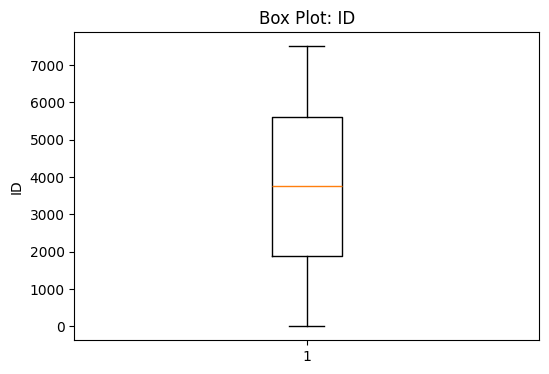

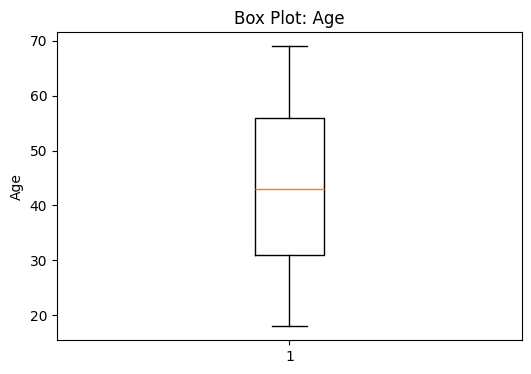

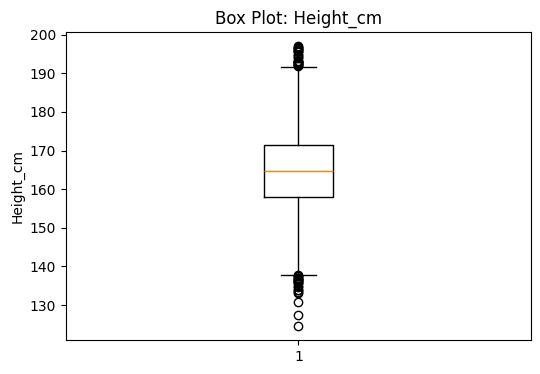

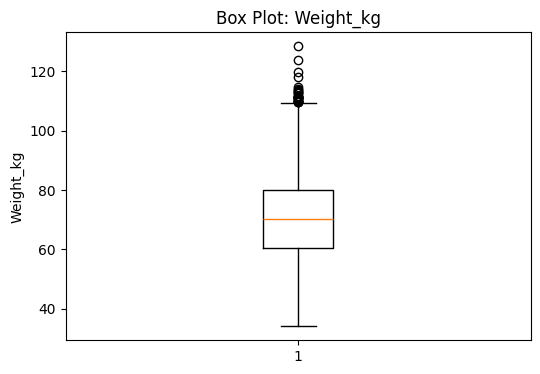

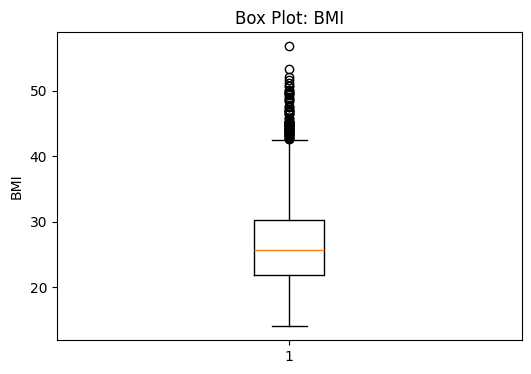

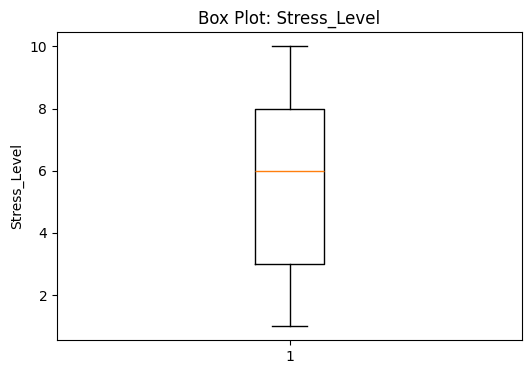

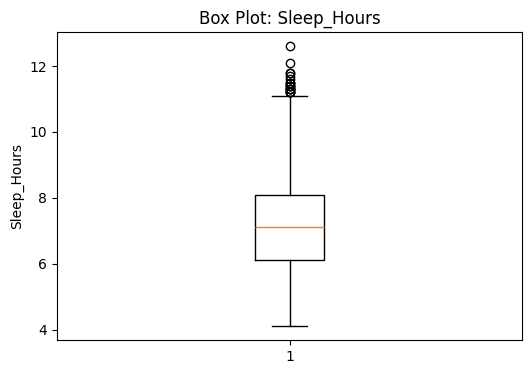

In [24]:
# Simple plots to visualise outliers in numerical data
import matplotlib.pyplot as plt

# Create box plots for numerical columns to spot outliers
numerical_cols = df.select_dtypes(include=[np.number]).columns

print("Creating box plots to spot outliers...")
print("Look for dots outside the boxes - these might be outliers!")

# Create a plot for each numerical column
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Box Plot: {col}')
    plt.ylabel(col)
    plt.show()

## 7. Save Your Clean Data

Once you're happy with your data cleaning, save it to a new file.

In [25]:
df.to_csv('health_cleaned_data.csv', index=False)  # Uncomment to save